# 설치된 라이브러리 확인

In [8]:
import sys, platform
from importlib.metadata import version, PackageNotFoundError
import requests

def get_ver(pkg: str) -> str:
    try:
        return version(pkg)
    except PackageNotFoundError:
        return "not installed"

def check_lm_studio() -> str:
    try:
        response = requests.get("http://localhost:1234/v1/models", timeout=2)
        if response.status_code == 200:
            return "connected ✓"
        else:
            return "server error"
    except:
        return "not running ✗"

print("Python:", sys.version.split()[0])
print("OS:", platform.platform())
print("langgraph:", get_ver("langgraph"))
print("openai:",get_ver("openai"))
print("LM Studio Server:", check_lm_studio())
print("typing_extensions:", get_ver("typing_extensions"))

Python: 3.12.12
OS: Windows-11-10.0.26100-SP0
langgraph: 1.0.4
openai: 2.8.1
LM Studio Server: connected ✓
typing_extensions: 4.15.0


In [9]:
from openai import OpenAI

# LM Studio 엔드포인트와 임의 API 키
client = OpenAI(
    base_url="http://localhost:1234/v1",
    api_key="lm-studio"  # 임의 문자열 가능
)

# 간단한 헬스체크
models = client.models.list()
print("Models:", [m.id for m in models.data])

def chat_local(prompt: str, model: str = None, temperature: float = 0.2) -> str:
    """LM Studio 호환 Chat Completions 호출"""
    model = model or (models.data[0].id if models.data else "meta-llama-3.1-8b-instruct")
    resp = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=temperature,
    )
    return resp.choices[0].message.content.strip()

Models: ['llama-3-korean-bllossom-8b', 'llama-3-korean-bllossom-8b:2', 'text-embedding-nomic-embed-text-v1.5']


# Hello, Graph
* LangGraph 모델(상태→노드→엣지) 파악
* 무엇:
    * 상태 {"input","output"}
    * echo_node 하나 + START→echo→END
* 관찰: output에 Echo: ... 반환

In [10]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

In [11]:
class S1(TypedDict):
    input: str      # key나 값을 입력하는 것이 아닌 어떤 데이터가 들어갈것인지 전달
    output: str

g1 = StateGraph(S1)

In [13]:
# 노드에서 사용할 에이전트
def echo_node(state: S1) -> S1:
    return {    # return 값은 state를 업데이트!
        "output": f"Echo: {state['input']}"
    }

In [14]:
# 노드 생성
g1.add_node("echo", echo_node)

# 엣지 연결 생성
g1.add_edge(START, "echo")
g1.add_edge("echo", END)

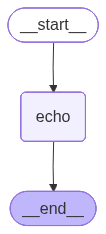

In [15]:
# Graph Compile -> 유효성 검사
app1 = g1.compile()

app1 # 그래프 출력

In [16]:
# invoke로 값 입력 후 실행
app1.invoke({"input": "LangGraph 첫 그래프!"})

{'input': 'LangGraph 첫 그래프!', 'output': 'Echo: LangGraph 첫 그래프!'}

# LLM node 추가
* LLM 호출을 그래프 **노드로 캡슐화하는 법 익히기**
* 무엇:
    * 상태 {"question","answer"}
    * llm_node 내부에서 chat_local() 호출
    * START→llm→END
* 관찰: answer에 한 줄 답 도착

In [17]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

In [18]:
# State 정의
class S2(TypedDict):
    question: str
    answer: str

g2 = StateGraph(S2)

In [19]:
# 에이전트 정의
def echo_node(state: S2) -> S2:
    print("Echo Node ->", state)
    return {    
        "question": f"Echo: {state['question']}"
    } 

def llm_node(state: S2) -> S2:
    ans = chat_local(f"한 문장으로 답해줘: {state['question']}")
    print("LLM Node ->", state)
    return {"answer": ans}

In [20]:
# 노드 추가
g2.add_node("echo_node", echo_node)
g2.add_node("llm_node", llm_node)

# 엣지 연결 추가
g2.add_edge(START, "llm_node")
g2.add_edge("llm_node", "echo_node")
g2.add_edge("echo_node", END)
app2 = g2.compile()

In [21]:
# 실행!
app2.invoke({"question": "LangGraph는 무엇인가?"})

LLM Node -> {'question': 'LangGraph는 무엇인가?'}
Echo Node -> {'question': 'LangGraph는 무엇인가?', 'answer': 'LangGraph는 자연어 처리(NLP) 분야에서 언어 모델을 그래프로 표현하고, 이를 통해 언어 구조와 의미 관계를 시각적으로 분석하고 이해하는 도구입니다.'}


{'question': 'Echo: LangGraph는 무엇인가?',
 'answer': 'LangGraph는 자연어 처리(NLP) 분야에서 언어 모델을 그래프로 표현하고, 이를 통해 언어 구조와 의미 관계를 시각적으로 분석하고 이해하는 도구입니다.'}

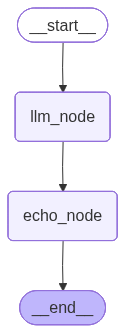

In [22]:
app2

In [23]:
# 실행!
app2.invoke({"question": "크리스티아누 호날두의 생일은 언제야?"})

LLM Node -> {'question': '크리스티아누 호날두의 생일은 언제야?'}
Echo Node -> {'question': '크리스티아누 호날두의 생일은 언제야?', 'answer': '크리스티아누 호날두의 생일은 5월 20일입니다.'}


{'question': 'Echo: 크리스티아누 호날두의 생일은 언제야?',
 'answer': '크리스티아누 호날두의 생일은 5월 20일입니다.'}

호날두 2월 5일 생인데 ㅠ.ㅠ

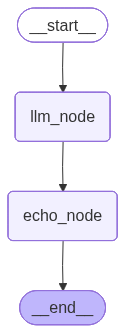

In [24]:
app2

# Conditional Edge
* 간단한 분기 생성
* 입력 유효성 검사 및 흐름 제어
* 무엇:
    * 상태 {"question","result"}
    * route_fn으로 빈 입력 시 종료, 아니면 처리
    * add_conditional_edges("validate", route_fn, {"empty": END, "ok": "answer"})
* 관찰: 빈 입력은 종료, 유효 입력은 답변 노드로 이동

In [25]:
from typing_extensions import TypedDict

class S3(TypedDict):
    question: str
    result: str

def validate(state: S3) -> S3:
    q = (state.get("question") or "").strip()
    return {"result": "빈 질문"}

def answer(state: S3) -> S3:
    q = state["question"]
    a = chat_local(f"간단히 답해줘: {q}")
    return {"result": a}

def route_fn(state: S3) -> str:
    if not (state.get("question") or "").strip():
        return "empty"
    return "ok"

g3 = StateGraph(S3)
g3.add_node("validate", validate)
g3.add_node("answer", answer)
g3.add_edge(START, "validate")
g3.add_conditional_edges("validate", route_fn, {"empty": END, "ok": "answer"})
g3.add_edge("answer", END)
app3 = g3.compile()

print(app3.invoke({"question": ""}))
print(app3.invoke({"question": "Conditional Edge는 언제 쓰나?"}))

{'question': '', 'result': '빈 질문'}
{'question': 'Conditional Edge는 언제 쓰나?', 'result': 'Conditional Edge는 다음과 같은 상황에서 사용됩니다:\n\n1. **조건부 이벤트**: 특정 조건이 만족될 때만 Edge가 생성되거나 활성화되는 경우.\n2. **상태 변화 감지**: 상태 변화를 감지하여 Edge를 트리거할 때.\n3. **데이터 기반 결정**: 데이터의 특정 패턴이나 값에 따라 Edge를 설정할 때.\n\n예: "온도 25도 이상이면 알림을 보낸다"와 같이, 특정 조건이 만족될 때만 Edge가 발생하는 경우입니다.'}


# Reducer(상태 합치기)
* 여러 노드 결과를 **한 키(리스트)로 안전히 누적**
* 무엇:
    * 상태에 facts: Annotated[list[str], operator.add]
    * fact_a, fact_b가 각각 한 문장 생성 → 리스트 병합
* 관찰: facts에 2개 이상 항목이 합쳐져 반환
* 이슈: reducer 미지정 시 덮어쓰기 발생

In [26]:
from typing_extensions import Annotated, TypedDict
import operator

class S4(TypedDict):
    topic: str
    facts: Annotated[list[str], operator.add]  # 리스트를 합치는 규칙

def fact_a(state: S4) -> S4:
    t = state["topic"]
    return {"facts": [chat_local(f"{t}에 대해 핵심 사실 1가지를 1문장으로.", temperature=0.1)]}

def fact_b(state: S4) -> S4:
    t = state["topic"]
    return {"facts": [chat_local(f"{t}에 대해 추가 사실 1가지를 1문장으로.", temperature=0.1)]}

g4 = StateGraph(S4)
g4.add_node("fact_a", fact_a)
g4.add_node("fact_b", fact_b)
g4.add_edge(START, "fact_a")
g4.add_edge("fact_a", "fact_b")
g4.add_edge("fact_b", END)
app4 = g4.compile()

app4.invoke({"topic": "LangGraph"})

{'topic': 'LangGraph',
 'facts': ['LangGraph는 자연어 처리(NLP) 모델을 위한 그래프 기반의 데이터 구조를 제공하여, 문맥과 의미 관계를 효율적으로 관리하고 분석할 수 있게 합니다.',
  'LangGraph는 자연어 처리(NLP) 분야에서 언어 모델과 그래프 네트워크를 결합하여 텍스트의 의미 구조와 관계를 분석하고 이해하는 데 사용되는 도구입니다.']}

In [28]:
app4.invoke({"topic": "마라도나의 신의 손"})

{'topic': '마라도나의 신의 손',
 'facts': ['마라도나의 "신의 손"은 그의 엄청난 실력과 경기 내에서의 통제력을 의미하며, 이는 그가 경기를 시작하기 전에 공을 잡아야 하는 특수한 기술로 표현된다.',
  '마라도나의 "신의 손"은 그의 왼손을 가리키며, 이는 그가 왼발로 골을 넣는 것처럼 의외한 상황에서도 왼손이 중요한 역할을 한다는 의미를 담고 있습니다.']}

# 체크포인트 & 스트리밍
* 실행 추적/디버깅/재실행(thread)
* 무엇:
    * MemorySaver checkpointer
    * 같은 thread_id로 app.stream(..., stream_mode="values") 두 번 실행
* 관찰: 중간 상태가 흘러나오고, 재실행도 로그가 보임
* 이슈: stream_mode="values"와 thread_id 누락 주의

In [29]:
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

# 이전 상태 재사용 가능한 간단 그래프
class S5(TypedDict):
    text: str
    steps: Annotated[list[str], operator.add]

def step1(state: S5) -> S5:
    return {"steps": [f"입력 길이: {len(state['text'])}"]}

def step2(state: S5) -> S5:
    s = chat_local(f"요약: {state['text']}")
    return {"steps": [f"요약완료({len(s)}자)"]}

g5 = StateGraph(S5)
g5.add_node("step1", step1)
g5.add_node("step2", step2)
g5.add_edge(START, "step1")
g5.add_edge("step1", "step2")
g5.add_edge("step2", END)
app5 = g5.compile(checkpointer=checkpointer)

thread = {"configurable": {"thread_id": "demo-1"}}

print("== 1차 실행 ==")
for update in app5.stream({"text": "LangGraph는 상태+노드+엣지로 구성된 워크플로우 엔진."}, thread, stream_mode="values"):
    print(update)

print("\n== 2차 실행(같은 thread_id) ==")
for update in app5.stream({"text": "같은 스레드에서 두 번째 실행"}, thread, stream_mode="values"):
    print(update)

== 1차 실행 ==
{'text': 'LangGraph는 상태+노드+엣지로 구성된 워크플로우 엔진.', 'steps': []}
{'text': 'LangGraph는 상태+노드+엣지로 구성된 워크플로우 엔진.', 'steps': ['입력 길이: 34']}
{'text': 'LangGraph는 상태+노드+엣지로 구성된 워크플로우 엔진.', 'steps': ['입력 길이: 34', '요약완료(123자)']}

== 2차 실행(같은 thread_id) ==
{'text': '같은 스레드에서 두 번째 실행', 'steps': ['입력 길이: 34', '요약완료(123자)']}
{'text': '같은 스레드에서 두 번째 실행', 'steps': ['입력 길이: 34', '요약완료(123자)', '입력 길이: 16']}
{'text': '같은 스레드에서 두 번째 실행', 'steps': ['입력 길이: 34', '요약완료(123자)', '입력 길이: 16', '요약완료(1106자)']}


# Send / Command
* 동적 fan-out
* 한 개 입력에 포함된 여러 sub-question을 계획 -> 병렬 답변 -> 모으기 흐름으로 처리
* 하나의 입력을 여러 하위 작업(질문들)으로 병렬 처리
* 무엇:
    * 상태:
        * questions: Annotated[list[str], operator.add]
        * answers:   Annotated[list[str], operator.add]
    * plan 노드: raw 텍스트를 ? 기준으로 분리해 questions에 저장
    * 핵심: add_conditional_edges("plan", fanout)에서 fanout이
    return [Send("qa", {"question": q}) for q in state["questions"]] 반환
    * qa 노드: state["question"]를 읽고 답 생성 → answers에 1개씩 추가
    * 엣지: START→plan, qa→join, join→END
* 관찰:
   * 스트리밍: {'questions': [...]} 후 {'answers': ['Q: ... | A: ...']}가 여러 번 출력
   * 최종 상태에서 모든 Q/A가 answers에 누적
* 이슈:
   * answers가 비면
    ① 리듀서 누락(반드시 Annotated[..., operator.add])
    ② 팬아웃 미실행(조건 엣지/Send 반환 확인)
    ③ qa에서 question 접근 방식 확인(state["question"])

In [30]:
from typing_extensions import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
import operator

# 1) 상태: 리스트 병합 규칙 꼭 지정
class S(TypedDict):
    raw: str
    questions: Annotated[list[str], operator.add]
    answers:   Annotated[list[str], operator.add]

# 2) plan: 질문 리스트만 상태에 기록
def plan(state: S):
    qs = [p.strip()+"?" for p in state["raw"].split("?") if p.strip()]
    return {"questions": qs}

# 3) fanout(조건 엣지 함수): qa로 Send 목록 반환  ← 핵심!
def fanout(state: S):
    return [Send("qa", {"question": q}) for q in state["questions"]]

# 4) qa: Send로 넘어온 입력(arg)에 'question'이 담겨옴
def qa(state: S) -> S:
    q = state.get("question", "")
    a = chat_local(f"아주 짧게 대답해줘: {q}", temperature=0.1) or ""
    return {"answers": [f"Q: {q} | A: {a.strip()}"]}

# 5) join: 마무리(패스스루)
def join(state: S) -> S:
    return {}

# 6) 그래프 구성
g = StateGraph(S)
g.add_node("plan", plan)
g.add_node("qa", qa)
g.add_node("join", join)

g.add_edge(START, "plan")
# plan 다음 흐름을 '조건 엣지'로 정의 → qa가 질문 수만큼 실행됨
g.add_conditional_edges("plan", fanout)
# qa 실행이 끝난 뒤 join으로 수집
g.add_edge("qa", "join")
g.add_edge("join", END)

app = g.compile()

# 7) 실행
out = app.invoke({"raw": "LangGraph는 무엇인가? Conditional Edge는 언제 쓰나? Reducer는 왜 필요한가?"})

In [31]:
out

{'raw': 'LangGraph는 무엇인가? Conditional Edge는 언제 쓰나? Reducer는 왜 필요한가?',
 'questions': ['LangGraph는 무엇인가?',
  'Conditional Edge는 언제 쓰나?',
  'Reducer는 왜 필요한가?'],
 'answers': ['Q: LangGraph는 무엇인가? | A: LangGraph는 자연어 처리(NLP) 분야에서 언어 모델과 그래프를 결합하여 텍스트 데이터의 구조적 관계를 분석하고 이해하는 기술을 의미합니다.',
  'Q: Conditional Edge는 언제 쓰나? | A: Conditional Edge는 데이터가 특정 조건을 만족할 때만 표시되도록 하는 데 사용됩니다. 예를 들어, 특정 이벤트가 발생했을 때만 알림이 전송되는 등의 상황에서 유용합니다.',
  'Q: Reducer는 왜 필요한가? | A: Reducer는 상태 관리 라이브러리인 Redux에서 사용되며, 여러 개의 액션을 처리하여 하나의 상태로 통합하는 역할을 합니다. 이를 통해 컴포넌트 간의 상태 공유와 일관성을 유지할 수 있습니다.']}